In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append("../..")

from src.classifical_features import build_monthly_features
from src.configs.settings import Settings
from src.visualization.visualization import (
    plot_best_predictions,
    plot_overall_metrics_comparison,
    plot_panel_metrics_distributions,
    plot_worst_predictions,
)

settings = Settings()

In [2]:
data_dir = Path("../../data")

In [3]:
features_df = pd.read_csv(data_dir / "processed" / "mirrors_clusters.csv")
mirrors_ts_df = pd.read_csv(data_dir / "processed" / "filtered_mirrors_ts.csv")

In [4]:
features = build_monthly_features(mirrors_ts_df, settings)
features["panel_id"] = features[settings.columns.id].astype(str)

Processing panels: 100%|██████████| 805/805 [00:02<00:00, 296.76it/s]


In [5]:
from src.catboost_utilities.evaluate import evaluate_catboost
from src.catboost_utilities.train import train_catboost
from src.custom_types import CatBoostParameters
from src.model_selection import temporal_panel_split_by_size

regression_splits = temporal_panel_split_by_size(
    features,
    panel_column='article',
    time_column='date',
    test_size=3,
    val_size=None
)

In [6]:
from dataclasses import dataclass

import pandas as pd

from src.custom_types import Splits


@dataclass
class PanelSplitStats:
    """Статистики панели по сплитам."""
    
    panel_id: str
    train_mean: float
    test_mean: float
    train_std: float
    test_std: float
    mean_diff: float
    std_ratio: float


def compute_panel_split_stats(
    splits: Splits[pd.DataFrame],
    panel_column: str,
    target_column: str,
) -> list[PanelSplitStats]:
    """Вычисляет статистики по панелям для train/test сплитов."""
    train_stats = splits.train.groupby(panel_column)[target_column].agg(['mean', 'std'])
    test_stats = splits.test.groupby(panel_column)[target_column].agg(['mean', 'std'])
    
    result = []
    for panel_id in train_stats.index:
        if panel_id not in test_stats.index:
            continue
        
        train_mean, train_std = train_stats.loc[panel_id]
        test_mean, test_std = test_stats.loc[panel_id]
        
        result.append(PanelSplitStats(
            panel_id=panel_id,
            train_mean=train_mean,
            test_mean=test_mean,
            train_std=train_std,
            test_std=test_std,
            mean_diff=abs(test_mean - train_mean),
            std_ratio=test_std / train_std if train_std > 0 else float('inf'),
        ))
    
    return result


def find_ood_panels(
    splits: Splits[pd.DataFrame],
    panel_column: str,
    target_column: str,
    mean_diff_threshold: float | None = None,
    std_ratio_threshold: float | None = None,
    z_score_threshold: float | None = 2.0,
) -> list[PanelSplitStats]:
    """Находит панели с out-of-distribution test данными."""
    stats = compute_panel_split_stats(splits, panel_column, target_column)
    
    ood_panels = []
    for s in stats:
        is_ood = False
        
        if mean_diff_threshold is not None and s.mean_diff > mean_diff_threshold:
            is_ood = True
        
        if std_ratio_threshold is not None:
            if s.std_ratio > std_ratio_threshold or s.std_ratio < 1 / std_ratio_threshold:
                is_ood = True
        
        if z_score_threshold is not None and s.train_std > 0:
            z_score = s.mean_diff / s.train_std
            if z_score > z_score_threshold:
                is_ood = True
        
        if is_ood:
            ood_panels.append(s)
    
    return sorted(ood_panels, key=lambda x: x.mean_diff, reverse=True)


def filter_ood_panels(
    splits: Splits[pd.DataFrame],
    panel_column: str,
    target_column: str,
    mean_diff_threshold: float | None = None,
    std_ratio_threshold: float | None = None,
    z_score_threshold: float | None = 2.0,
    print_stats: bool = False,
) -> tuple[Splits[pd.DataFrame], list[PanelSplitStats]]:
    """Фильтрует панели с OOD test данными и возвращает отфильтрованные сплиты."""
    ood_panels = find_ood_panels(
        splits, panel_column, target_column,
        mean_diff_threshold, std_ratio_threshold, z_score_threshold
    )
    
    ood_ids = {s.panel_id for s in ood_panels}
    
    def _filter_df(df: pd.DataFrame) -> pd.DataFrame:
        return df[~df[panel_column].isin(ood_ids)].reset_index(drop=True)
    
    filtered_splits = splits.apply(_filter_df)
    
    if print_stats:
        total_panels = splits.train[panel_column].nunique()
        filtered_count = len(ood_panels)
        remaining = total_panels - filtered_count
        print(
            f"OOD фильтрация: {filtered_count}/{total_panels} панелей удалено "
            f"({filtered_count / total_panels * 100:.1f}%), осталось {remaining}"
        )
    
    return filtered_splits, ood_panels

In [7]:
filtered_splits, ood_panels = filter_ood_panels(
    regression_splits,
    panel_column='article',
    target_column='sales',
    z_score_threshold=2.0,
    print_stats=True,
)

pd.DataFrame([vars(p) for p in ood_panels])

OOD фильтрация: 121/805 панелей удалено (15.0%), осталось 684


,panel_id,train_mean,test_mean,train_std,test_std,mean_diff,std_ratio
0,187242297,36.400000,612.666667,44.327569,269.147419,576.266667,6.071784
1,202447972,26.875000,500.666667,24.827620,340.916901,473.791667,13.731356
2,225928414,138.333333,609.666667,108.649283,154.001082,471.333333,1.417415
3,51165892,80.500000,444.000000,49.271357,703.193430,363.500000,14.271850
4,212007803,224.250000,571.666667,154.782566,190.421462,347.416667,1.230251
...,...,...,...,...,...,...,...
116,235339204,1.666667,4.000000,1.154701,3.464102,2.333333,3.000000
117,223785597,2.000000,4.000000,0.816497,2.645751,2.000000,3.240370
118,224227058,1.400000,3.000000,0.547723,2.000000,1.600000,3.651484
119,227696859,1.250000,2.666667,0.500000,1.527525,1.416667,3.055050


In [8]:
from src.data_processing import scale_panel_splits

scale = not settings.downstream.round_predictions
if scale:
    splits = scale_panel_splits(
        (data for _, data in regression_splits.splits),
        panel_column=settings.columns.id,
        target_columns=settings.columns.main_target,
        apply_log=settings.preprocessing.apply_log,
    )
else:
    splits = regression_splits

In [9]:
catboost_params = CatBoostParameters(
    iterations=500,
    learning_rate=0.05,
    depth=3,
    l2_leaf_reg=10,
    subsample=0.8,
    rsm=0.8,
    random_seed=settings.random_state,
    verbose=50,
    loss_function="RMSE",
)

catboost_model = train_catboost(
    train_df=splits.train,
    val_df=splits.val,
    params=catboost_params,
    settings=settings,
)

results = evaluate_catboost(
    model=catboost_model,
    splits=splits,
    settings=settings,
    scalers=None,
)

0:	learn: 107.9473558	total: 46.9ms	remaining: 23.4s
50:	learn: 73.7131021	total: 72.7ms	remaining: 640ms
100:	learn: 63.1795784	total: 103ms	remaining: 405ms
150:	learn: 59.4828461	total: 129ms	remaining: 298ms
200:	learn: 56.4350522	total: 155ms	remaining: 230ms
250:	learn: 54.4300992	total: 181ms	remaining: 179ms
300:	learn: 52.5718672	total: 208ms	remaining: 138ms
350:	learn: 51.0498508	total: 235ms	remaining: 100ms
400:	learn: 49.7536602	total: 262ms	remaining: 64.6ms
450:	learn: 48.1554500	total: 289ms	remaining: 31.4ms
499:	learn: 46.4813352	total: 312ms	remaining: 0us


Evaluating test panels: 100%|██████████| 805/805 [00:00<00:00, 1915.52it/s]


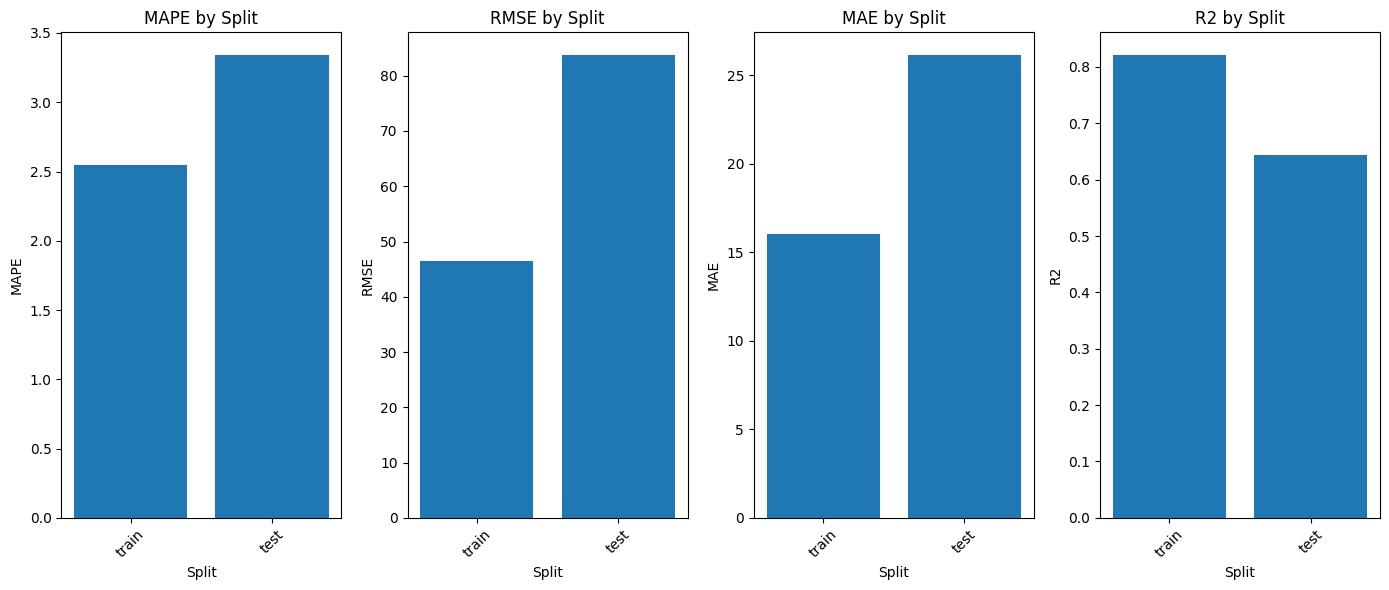

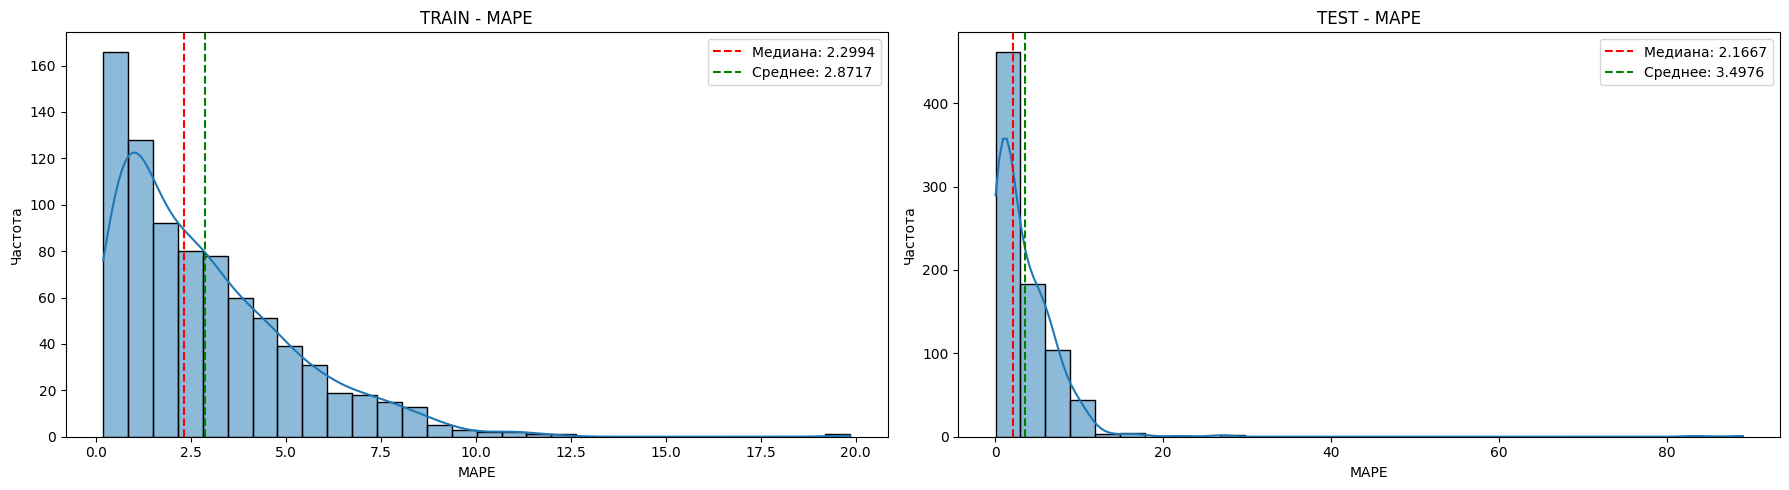

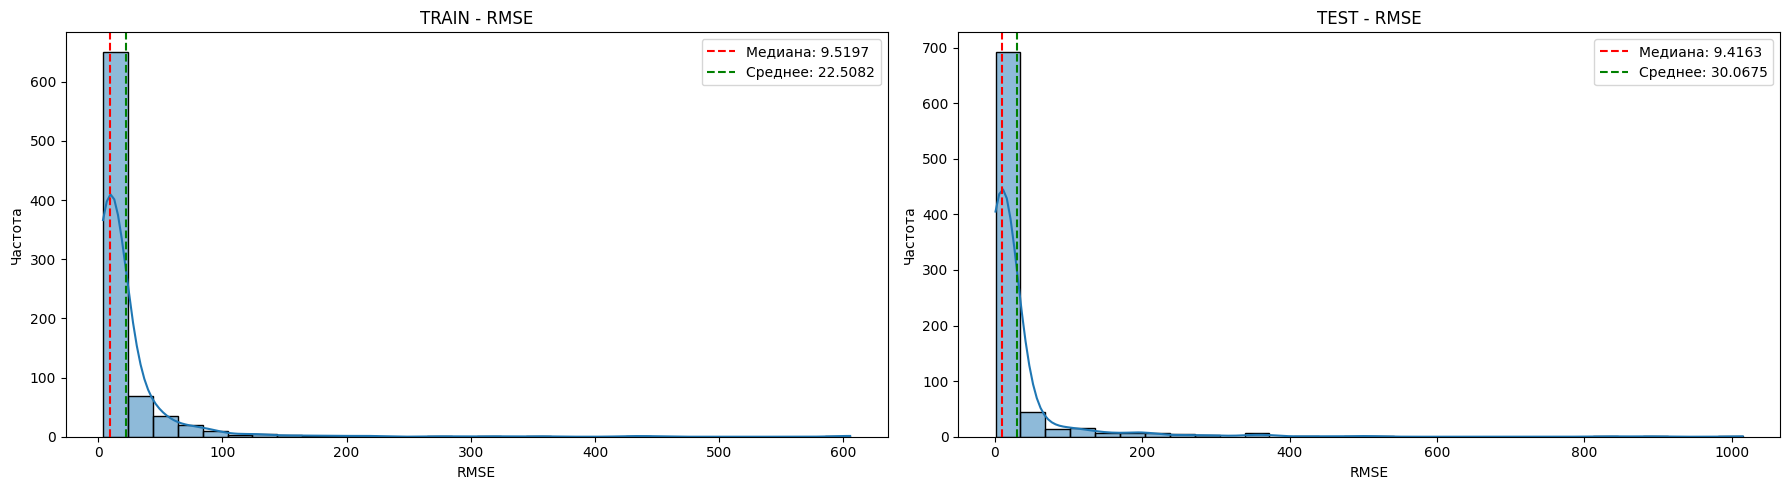

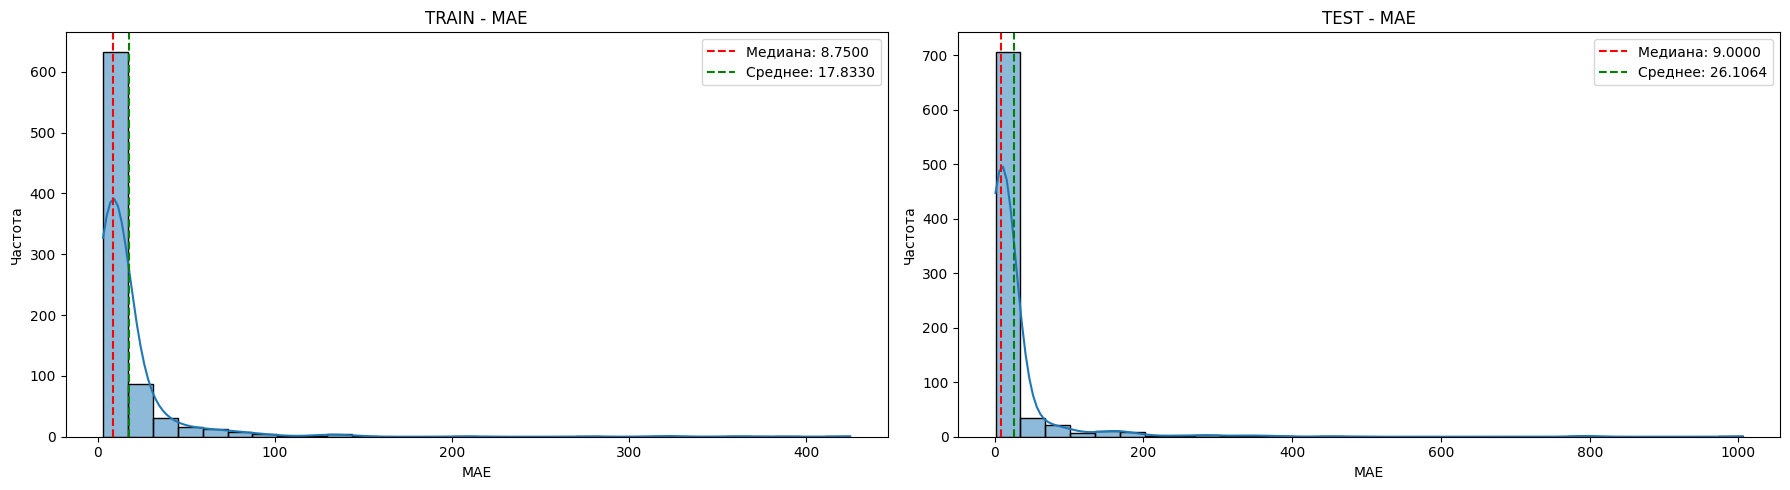

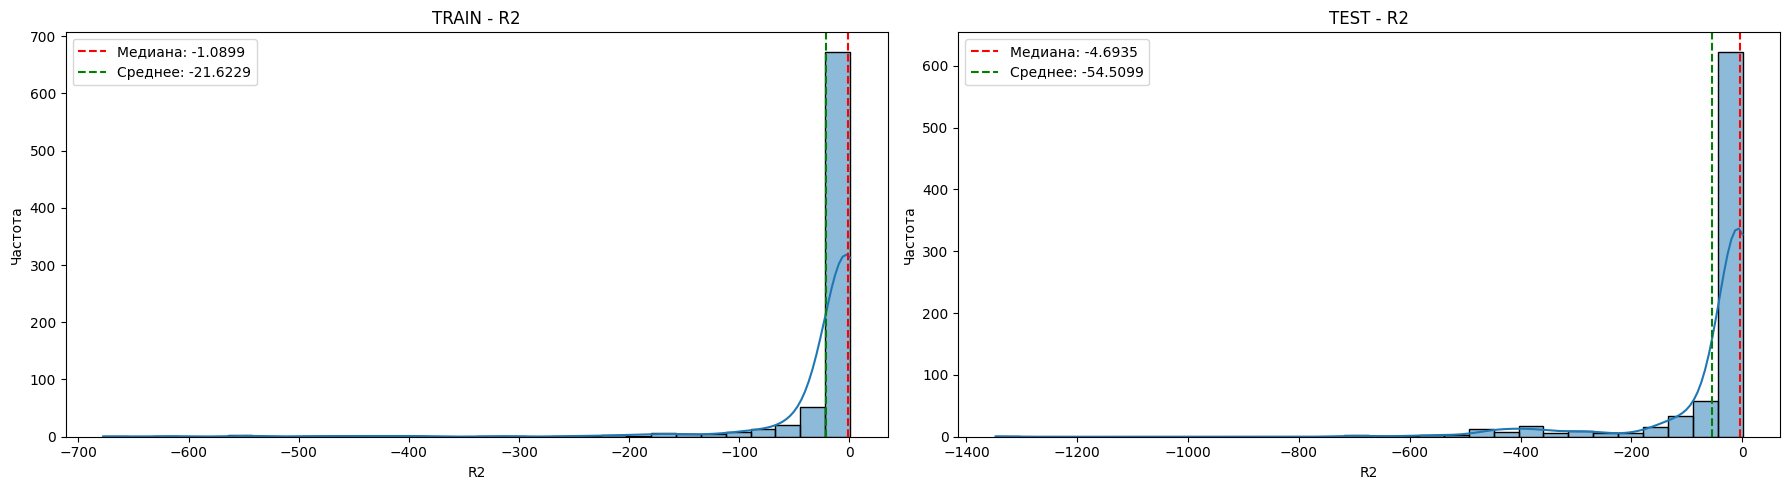

In [10]:
overall_df = results.get_overall_metrics_df()
panel_df = results.get_panel_metrics_df()


plot_overall_metrics_comparison(results)

plot_panel_metrics_distributions(
    results=results,
    metrics_to_plot=["mape", "rmse", "mae", "r2"],
)

In [11]:
plot_best_predictions(
    results=results,
    n_best=5,
    metric="rmse",
    split_name="test",
)

In [12]:
plot_worst_predictions(
    results=results,
    n_worst=5,
    metric="rmse",
    split_name="test",
)

In [14]:
feature_importance = catboost_model.get_feature_importance()
feature_names = regression_splits.train.drop(
    columns=[settings.columns.main_target, settings.columns.id, settings.columns.date]
).columns

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importance,
    }
).sort_values("importance", ascending=False)

importance_df

,feature,importance
9,panel_mean,15.809420
10,panel_std,12.744274
0,sales_lag_1,11.842074
3,sales_ma_2,10.641449
5,sales_ema_2,8.602169
4,sales_ma_3,8.033895
6,sales_ema_3,7.396928
16,panel_id,5.725072
1,sales_lag_2,5.452493
2,sales_lag_3,4.603611
